In [2]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import math
from datetime import datetime
from PIL import Image
from skimage import color
from skimage import io
import cv2

# Load data

In [3]:
#file_name = '20220730/pass_288_191616_rfc/frame_c307_20220730_191630_sky_bluesky.png'
#file_name = '20220730/pass_288_191616_rfc/frame_c307_20220730_191627_sky_bluesky.png'
dataset = xr.open_dataset('core_faam_20220726_v005_r0_c304_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')

In [4]:
file_name = '20220726/pass_182_172122_ffc/frame_c304_20220726_172055_sky_bluesky.png' # ffc
#file_name = '20220726/pass_182_172122_ffc/frame_c304_20220726_172105_sky_bluesky.png' # rfc
#file_name = '20220726/pass_182_172122_ffc/frame_c304_20220726_172110_sky_bluesky.png'
#file_name = '20220727/pass_212_164120_rfc/frame_c305_20220727_164141_sky_bluesky.png'# far
#file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163609_sky_bluesky.png'# near
#file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163545_sky_bluesky.png'# far

# Functions to extract air craft data, cloud position and distance camera to cloud

In [5]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [6]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [7]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [8]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['PALT_RVS'].data[:]
    veln = dataset['VELN_GIN'].data[:]
    vele = dataset['VELE_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle, 'veln': veln, 'vele': vele})
    return aircraft_df


In [9]:
def extract_cloud_pass_info(cloud_passes, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    cloud_lat1 = pass_info['start_lat']
    cloud_lon1 = pass_info['start_lon']
    cloud_lat2 = pass_info['end_lat']
    cloud_lon2 = pass_info['end_lon']
    start_time = datetime.strptime(pass_info['start_datetime'], '%Y-%m-%d %H:%M:%S')
    end_time = datetime.strptime(pass_info['end_datetime'], '%Y-%m-%d %H:%M:%S')
    return [cloud_lat1, cloud_lon1, cloud_lat2, cloud_lon2, start_time, end_time]

In [10]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [11]:
# Get the distance
#extract info
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, pass_number)
pass_lat1, pass_lon1, pass_lat2, pass_lon2, start_time, end_time = pass_info
# get mid pass time and thus the aircraft position at that time
mid_pass_time = start_time + (end_time - start_time)/2
aircraft_pass_position = get_closest_roll_angle(aircraft_df, mid_pass_time)

# Check roll
if abs(aircraft_position['roll_angles']) > 10:
    print('Aircraft is not level')
elif abs(aircraft_pass_position['roll_angles']) > 10:
    print('Aircraft is not level')
        



In [12]:
D1 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon1, pass_lat1, aircraft_pass_position['alt'])
D2 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon2, pass_lat2, aircraft_pass_position['alt'])
D = (D1 + D2)/2

In [13]:
print('Distance to cloud start: ', D1)

Distance to cloud start:  3736.2358183277984


In [14]:
print('Distance to cloud end: ', D2)

Distance to cloud end:  4975.952537793498


In [15]:
print('Distance to cloud mid: ', D)

Distance to cloud mid:  4356.094178060648


In [16]:
aircraft_pass_position

times          2022-07-26 17:21:26
lat                        34.0098
lon                    -107.154625
pitch                     2.930038
alt                    4354.468262
roll_angles              -0.138744
veln                     79.041672
vele                   -112.964531
Name: 15646, dtype: object

# find pixel height

In [17]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 155
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 325

In [18]:
%%bash

ls 20220730/pass_288_*_rfc/frame_c307_20220730_191630_sky_bluesky.png

20220730/pass_288_191616_rfc/frame_c307_20220730_191630_sky_bluesky.png


In [19]:


img = io.imread(file_name)
img_grey = color.rgb2gray(img)

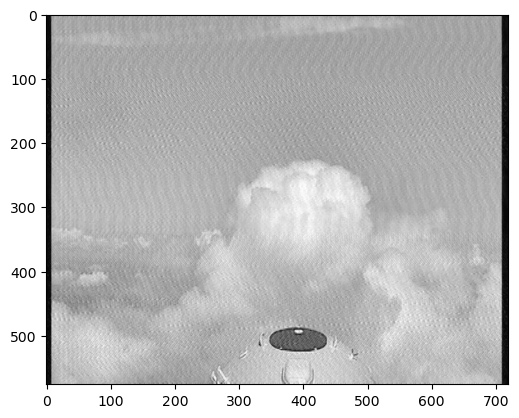

In [20]:
plt.imshow(img_grey,cmap='gray')  
 

In [21]:
img_grey = cv2.bilateralFilter(img, 18,175, 175)
mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
img_grey[~mask] = 0
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
# Apply a horizontal Sobel filter
sobelx = cv2.Sobel(cv_grey, cv2.CV_64F, 1, 0, ksize=1)

edges = cv2.Canny(cv_grey, 50, 250)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0

# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

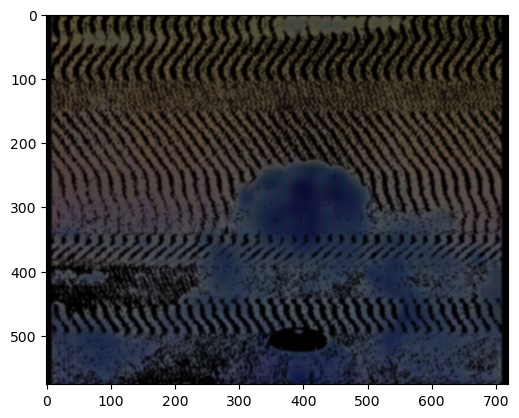

In [22]:

plt.imshow(cv_grey, cmap='gray')

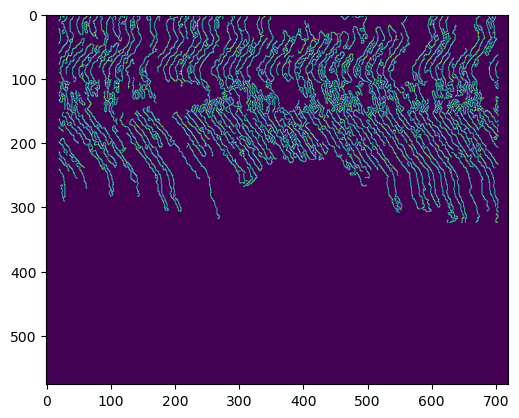

In [23]:

plt.imshow(edges)

In [24]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[66, 21, 19],
        [67, 22, 20],
        [54, 18,  8],
        ...,
        [46, 10, 34],
        [50, 15, 28],
        [45, 10, 23]],

       [[70, 25, 23],
        [65, 20, 18],
        [54, 18,  8],
        ...,
        [46, 10, 34],
        [49, 14, 27],
        [48, 13, 26]],

       [[54, 37, 19],
        [43, 26,  8],
        [40, 20, 10],
        ...,
        [ 7, 15, 37],
        [ 0, 24, 27],
        [ 0, 21, 24]],

       ...,

       [[38, 28, 14],
        [34, 24, 10],
        [38, 29,  8],
        ...,
        [ 0, 23, 19],
        [ 6,  9, 34],
        [ 9, 12, 37]],

       [[19, 23, 18],
        [17, 21, 16],
        [28, 29, 16],
        ...,
        [34, 21,  3],
        [38, 10, 17],
        [42, 14, 21]],

       [[16, 20, 15],
        [16, 20, 15],
        [29, 30, 17],
        ...,
        [33, 20,  2],
        [38, 10, 17],
        [44, 16, 23]]], dtype=uint8)

In [25]:
cv2.imwrite('cloud_edge.png', edge_image)

True

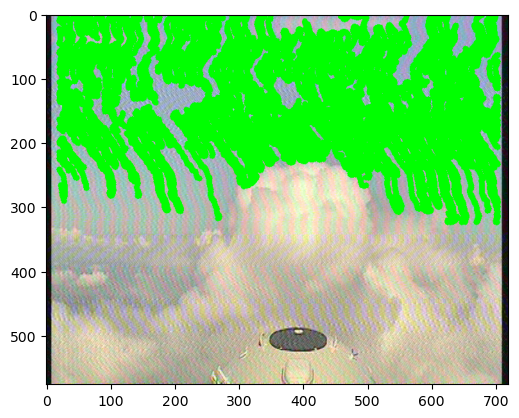

In [26]:
cloud_edge=Image.open('cloud_edge.png')
plt.imshow(cloud_edge)

photo is 720 pixels wide plane nose looks off center could use 360 otr 380 in line with nose?

In [27]:
x_target = 380
found_points = []

for contour in contours:
    for point in contour:
        # point is a 3D array: [[x, y]]
        x, y = point[0]
        if x == x_target:
            found_points.append((x, y))

if found_points:
    # If there are multiple points, you can decide how to handle them
    # Here, we'll just pick the first one for simplicity
    x, y = found_points[0]
    print(f"Contour intersects x={x_target} at y={y}")
else:
    print(f"No contours intersect x={x_target} trying to x={x_target+1}")
    x_target = 351
    found_points = []

    for contour in contours:
        for point in contour:
            # point is a 3D array: [[x, y]]
            x, y = point[0]
            if x == x_target:
                found_points.append((x, y))

    if found_points:
        # If there are multiple points, you can decide how to handle them
        # Here, we'll just pick the first one for simplicity
        x, y = found_points[0]
        print(f"Contour intersects x={x_target} at y={y}")
    else:
        print(f"No contours intersect x={x_target+1}")

Contour intersects x=380 at y=231


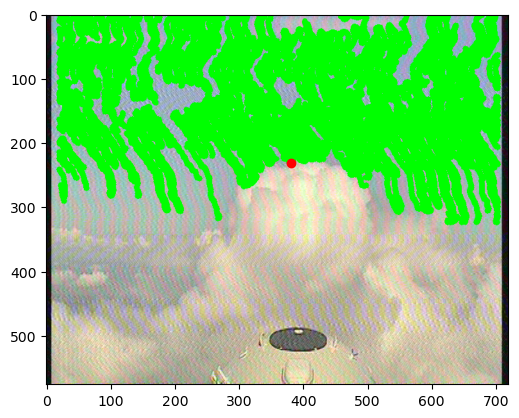

In [28]:
plt.imshow(cloud_edge)
plt.plot(x, y, 'ro')


In [29]:
pixel_height = 576- y


# find cloud height

[LTC3244/20](https://www.sourcesecurity.com/datasheets/bosch-ltc-3214-20/co-289-ga/FixedLenses.pdf)



In [30]:
focal_length_mm = 12        # Focal Length in mm
fov_vertical_deg = 23      # Field of View in degrees
fov_horizontal_deg = 30    # Field of View in degrees
FOV = 0         # Field of View (to be calculated later)


In [31]:
# Calculating FOV angles in degrees
# Convert FOV angles to radians
fov_horizontal_rad = math.radians(fov_horizontal_deg)
fov_vertical_rad = math.radians(fov_vertical_deg)
FOV = fov_vertical_deg

# Calculate sesnor height and width in mm from FOV angles
sensor_width_mm = 2 * focal_length_mm * math.tan(fov_horizontal_rad / 2)
sensor_height_mm = 2 * focal_length_mm * math.tan(fov_vertical_rad / 2)



# Displaying FOV angles
print("FOV Horizontal Angle:", fov_horizontal_deg, "degrees")
print("FOV Vertical Angle:", fov_vertical_deg, "degrees")

FOV Horizontal Angle: 30 degrees
FOV Vertical Angle: 23 degrees


In [32]:
# Function to find height of an object given its pixel position on the sensor


def find_height(P, Distance, focal_length_mm, sensor_height_mm):
    """
    Calculate the height of an object given its pixel position on the sensor.

    Parameters:
    - P: Pixel position of the object on the photo
    - Distance: Distance to the object in km
    - focal_length_mm: Focal length of the camera lens in millimeters
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Height of the object in kilometers (rounded to 2 decimal places)
    """
    OHS = find_OHS(P, sensor_height_mm)
    H = (Distance * 10**3 * OHS) / focal_length_mm
    return round(H / 10**3, 2)

# Object height on sensor =  (Sensor height (mm) × Object height (pixels))
#                                      / Sensor height (pixels)
# Sensor height (px) = Sensor height (mm) / distance between pixels
# sensor_height_pixels = 24*10**-3 / 5.73*10**-6
# sensor_height_pixels = 4188

# Function to calculate Object Height on Sensor


def find_OHS(P, sensor_height_mm):
    """
    Calculate the Object Height on Sensor.

    Parameters:
    - P: Pixel position of the object on the photo
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Object Height on Sensor
    """
    # this value is a typical value for a 1/3" CCD sensor
    sensor_height_pixels =596
    OHS = sensor_height_mm * P / sensor_height_pixels
    return OHS


def pitch_correct(P, FieldOfView, h):
    """
    Correct the pitch of the camera based on angles and height.

    Parameters:
    - P: pitch in degrees
    - FieldOfView: Field of View of the camera in degrees
    - h: Height on the inclined plane

    Returns:
    - True height after pitch correction
    """
    # See diagram for agles a, b and c
    a = 90 - P - FieldOfView/2
    b = 180 - 90 - FieldOfView/2
    # image plane incline from vertical
    c = 180 - a - b
    # x is true height, h is height on inclined place
    x = h * math.cos(c)
    return x

In [33]:
CTH_raw= find_height(pixel_height, D, focal_length_mm, sensor_height_mm)
# check if +3 or minus 3
CTH_rel_to_plane = pitch_correct(-aircraft_position['pitch']+3, FOV, CTH_raw)


81.63803100585938
78.5


In [34]:
cloud_top_height = CTH_rel_to_plane + aircraft_position['alt']

In [35]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  4892.612597465912


In [36]:
print('the pass height was: ', aircraft_pass_position['alt'])

the pass height was:  4354.4683


In [37]:
CTH_rel_to_plane 

543.6121091846616